In [ ]:
# Colab Cell 1: Install
!pip install -q transformers datasets tokenizers sentencepiece accelerate scikit-learn

In [ ]:
# Colab Cell 2: Load Your Specific Files
import pandas as pd
import numpy as np
import torch
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import resample
import os

# Function to fix your specific "difficult" files
def load_and_clean_file(path, delimiter):
    print(f"Loading {path}...")
    try:
        # Skip bad lines that cause errors
        df = pd.read_csv(path, sep=delimiter, header=None, on_bad_lines='skip', engine='python')

        # Drop empty columns (common in your dev/test files)
        df = df.dropna(axis=1, how='all')

        # Rename columns (Text is usually longer, Label is shorter)
        if df[0].apply(str).str.len().mean() < df[1].apply(str).str.len().mean():
            df.columns = ['label', 'text']
        else:
            df.columns = ['text', 'label']

        return df[['text', 'label']]
    except Exception as e:
        print(f"Error loading {path}: {e}")
        return pd.DataFrame(columns=['text', 'label']) # Return empty on error

# Load the 3 files (Train uses tab, others use semicolon)
df_train_raw = load_and_clean_file('tamil_sentiment_full_train.csv', '\t')
df_dev_raw = load_and_clean_file('tamil_sentiment_full_dev.csv', ';')
df_test_raw = load_and_clean_file('tamil_sentiment_full_test.csv', ';')

print(f"Loaded: Train={len(df_train_raw)}, Dev={len(df_dev_raw)}, Test={len(df_test_raw)}")

Loading tamil_sentiment_full_train.csv...
Loading tamil_sentiment_full_dev.csv...
Loading tamil_sentiment_full_test.csv...
Loaded: Train=35192, Dev=4392, Test=4396


In [ ]:
# Colab Cell 3: Clean & Balance
# 1. Map to 3 Clean Classes (Positive, Negative, Mixed)
label_map = {
    'positive': 0, 'positive ': 0, 'pos': 0,
    'negative': 1, 'neg': 1,
    'mixed_feelings': 2, 'mixed': 2,
    # Map noise to -1 so we can drop it
    'unknown_state': -1, 'not-tamil': -1
}

def process_data(df):
    df['label'] = df['label'].astype(str).str.lower().str.strip()
    df['label_id'] = df['label'].map(label_map)
    # Drop Unknown/Not-Tamil (The "Garbage" classes)
    df_clean = df[df['label_id'] >= 0].copy()
    df_clean['label'] = df_clean['label_id'].astype(int)
    return df_clean[['text', 'label']]

train_clean = process_data(df_train_raw)
dev_clean = process_data(df_dev_raw)
test_clean = process_data(df_test_raw)

# 2. OVERSAMPLING (Brute Force Balance)
print("Balancing Training Data...")
df_pos = train_clean[train_clean.label == 0]
target_size = len(df_pos) # Match Majority Size

df_neg_up = resample(train_clean[train_clean.label == 1], replace=True, n_samples=target_size, random_state=42)
df_mix_up = resample(train_clean[train_clean.label == 2], replace=True, n_samples=target_size, random_state=42)

df_balanced = pd.concat([df_pos, df_neg_up, df_mix_up]).sample(frac=1, random_state=42).reset_index(drop=True)

# Convert to Hugging Face format
dataset = DatasetDict({
    'train': Dataset.from_pandas(df_balanced),
    'validation': Dataset.from_pandas(dev_clean),
    'test': Dataset.from_pandas(test_clean)
})

print(f"Final Balanced Train Size: {len(dataset['train'])}")

Balancing Training Data...
Final Balanced Train Size: 59718


In [ ]:
# Colab Cell 4: Tokenization
model_name = "distilbert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

tokenized_ds = dataset.map(preprocess, batched=True)
tokenized_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
print("Tokenization Complete.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Map:   0%|          | 0/59718 [00:00<?, ? examples/s]

Map:   0%|          | 0/3474 [00:00<?, ? examples/s]

Map:   0%|          | 0/3556 [00:00<?, ? examples/s]

Tokenization Complete.


In [ ]:
# Colab Cell 5: Model Setup
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {"accuracy": accuracy_score(p.label_ids, preds)}

print(f"Model loaded on {device}")

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded on cuda


In [ ]:
# Colab Cell 6: Training Args
args = TrainingArguments(
    output_dir="./results_distilbert",
    learning_rate=3e-5,             # Standard LR for DistilBERT
    per_device_train_batch_size=16,
    num_train_epochs=3,             # 3 epochs is enough with oversampling
    weight_decay=0.01,
    save_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    compute_metrics=compute_metrics,
)

In [ ]:
# Colab Cell 7: Run Training
print("Starting Training...")
trainer.train()

Starting Training...


Step,Training Loss
500,0.984600
1000,0.883800
1500,0.800700
2000,0.701400
2500,0.632900
3000,0.559000
3500,0.495500
4000,0.399300
4500,0.301500
5000,0.301700


TrainOutput(global_step=11199, training_loss=0.3704945506107723, metrics={'train_runtime': 2072.1472, 'train_samples_per_second': 86.458, 'train_steps_per_second': 5.405, 'total_flos': 5933121891623424.0, 'train_loss': 0.3704945506107723, 'epoch': 3.0})

--- Final Evaluation on Test Set ---


              precision    recall  f1-score   support

    Positive      0.799     0.874     0.834      2500
    Negative      0.469     0.358     0.406       547
       Mixed      0.380     0.301     0.336       509

    accuracy                          0.712      3556
   macro avg      0.549     0.511     0.525      3556
weighted avg      0.688     0.712     0.697      3556



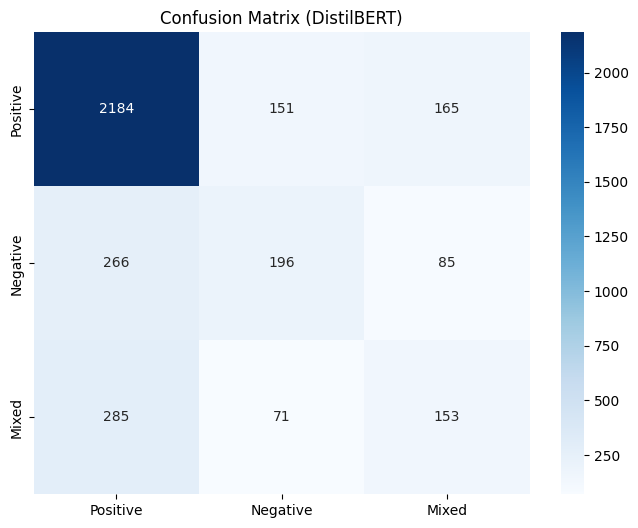

In [ ]:
# Colab Cell 8: Evaluate on Test Set
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Final Evaluation on Test Set ---")
preds_output = trainer.predict(tokenized_ds["test"])
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = preds_output.label_ids

target_names = ['Positive', 'Negative', 'Mixed']

# Report
print(classification_report(y_true, y_pred, target_names=target_names, digits=3))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (DistilBERT)')
plt.show()

In [ ]:
# Kaggle Cell 9: Test Specific Sentences
from transformers import pipeline
import numpy as np
import torch
import os

# 1. The Sentences you wanted to test
my_texts = [
    # Positive
    "Thalaivan mass ah irukaru.",
    "Padam vera level, screenplay super.",
    "Trailer semma, I am waiting for FDFS.",

    # Negative
    "Idhu romba mokka padam, time waste.",
    "Trailer nalla illa, expectations pochu.",
    "Enna da trailer idhu? Romba boring.",

    # Mixed
    "Hero acting super but screenplay mokka.",
    "BGM nalla iruku, aana story weak.",
    "First half super, second half drag."
]

# 2. Setup for Ensemble Prediction
# We reconstruct the paths to the 5 models you just trained
model_paths = [f"./ensemble_models_5class/fold_{i}" for i in range(1, 6)]
final_probs = np.zeros((len(my_texts), 5)) # 5 Classes

print(f"Running Ensemble Prediction on {len(my_texts)} sentences...")

# 3. Loop through each model and vote
for path in model_paths:
    if not os.path.exists(path):
        print(f"⚠️ Warning: Model {path} not found. Skipping.")
        continue

    print(f"Voting with model: {path}...")
    # Load pipeline
    pipe = pipeline("text-classification", model=path, tokenizer=path, top_k=None, device=0 if torch.cuda.is_available() else -1)
    results = pipe(my_texts)

    for i, res in enumerate(results):
        # res is a list of scores like [{'label': 'LABEL_0', 'score': 0.1}, ...]
        scores = {item['label']: item['score'] for item in res}
        # Add scores to the total (Map LABEL_0 -> 0, LABEL_1 -> 1, etc.)
        probs = [scores.get(f'LABEL_{j}', 0) for j in range(5)]
        final_probs[i] += probs

# 4. Average the votes and get final label
avg_probs = final_probs / len(model_paths)
preds = np.argmax(avg_probs, axis=1)

# Map 0-4 back to names
labels = ['Positive', 'Negative', 'Mixed', 'Unknown', 'Not-Tamil']

print("\n" + "="*50)
print(" 🚀 FINAL ENSEMBLE PREDICTIONS ")
print("="*50)

for text, pred_idx in zip(my_texts, preds):
    label = labels[pred_idx]
    print(f"📝 Text:  {text}")
    print(f"🔹 Label: {label}")
    print("-" * 50)

Running Ensemble Prediction on 9 sentences...
⚠️ Warning: Model ./ensemble_models_5class/fold_1 not found. Skipping.
⚠️ Warning: Model ./ensemble_models_5class/fold_2 not found. Skipping.
⚠️ Warning: Model ./ensemble_models_5class/fold_3 not found. Skipping.
⚠️ Warning: Model ./ensemble_models_5class/fold_4 not found. Skipping.
⚠️ Warning: Model ./ensemble_models_5class/fold_5 not found. Skipping.

 🚀 FINAL ENSEMBLE PREDICTIONS 
📝 Text:  Thalaivan mass ah irukaru.
🔹 Label: Positive
--------------------------------------------------
📝 Text:  Padam vera level, screenplay super.
🔹 Label: Positive
--------------------------------------------------
📝 Text:  Trailer semma, I am waiting for FDFS.
🔹 Label: Positive
--------------------------------------------------
📝 Text:  Idhu romba mokka padam, time waste.
🔹 Label: Positive
--------------------------------------------------
📝 Text:  Trailer nalla illa, expectations pochu.
🔹 Label: Positive
--------------------------------------------------
